In [2]:
from pymatgen.core import Structure
from datasets import load_dataset
import numpy as np

In [3]:
hf_dataset = load_dataset("LeMaterial/LeMat-Bulk-v2-Test", "compatible_pbe", split="train", num_proc=8)

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [4]:
# below is the processing code, you can instead load the preprocessed columns in data/cost_columns_only.npz
cost_columns = np.load("../data/cost_columns_only.npz", allow_pickle=True)
hf_dataset = hf_dataset.add_column("nbands", cost_columns["nbands"])
hf_dataset = hf_dataset.add_column("n_irr_kpts", cost_columns["n_irr_kpts"])
hf_dataset = hf_dataset.add_column("cost", cost_columns["cost"])

# from estimate_cost import get_cost_info_from_structure
# from pymatgen.core import Composition
# def apply_estimate_cost_to_hf_row(hf_row):
#     #construct composition dictionary from row["species_at_sites"]
#     species = hf_row["species_at_sites"]
#     try:
#         comp = {el: species.count(el) for el in set(species)}
#         Nbands, Nkpts, _, N_irr_kpts, cost = get_cost_info_from_structure(comp, lattice=np.array(hf_row["lattice_vectors"]), spg=hf_row["space_group_it_number"])
#         hf_row["nbands"] = Nbands
#         hf_row["nkpts"] = Nkpts
#         hf_row["n_irr_kpts"] = N_irr_kpts
#         hf_row["cost"] = cost
#         return hf_row
#     except Exception as e:
#         hf_row["nbands"] = None
#         hf_row["nkpts"] = None
#         hf_row["n_irr_kpts"] = None
#         hf_row["cost"] = None
#         return hf_row
# hf_dataset = dataset.map(apply_estimate_cost_to_hf_row, num_proc=8)
# nbands = np.array(hf_dataset["nbands"])
# n_irr_kpts = np.array(hf_dataset["n_irr_kpts"])
# cost = np.array(hf_dataset["cost"])
# np.savez("cost_columns_only.npz", nbands=nbands, n_irr_kpts=n_irr_kpts, cost=cost)

In [5]:
#query dataset for all structures in small_batches
from pymatgen.core import Structure
def get_structure_from_hf_row(row):
    """Get a pymatgen Structure from a dictionary.
    The dictionary should contain the following keys:
        - lattice_vectors: list of lists containing the lattice vectors
        - species_at_sites: list of species at each site
        - cartesian_site_positions: list of cartesian site positions

    Parameters
    ----------
    row : dict
        Dictionary containing the structure information.

    Returns
    -------
    pymatgen.Structure
        Pymatgen Structure object.
    """

    return Structure(
        lattice=[x for y in row["lattice_vectors"] for x in y],
        species=row["species_at_sites"],
        coords=row["cartesian_site_positions"],
        coords_are_cartesian=True,
    )


from concurrent.futures import ProcessPoolExecutor

def get_pair(row):
    # Adjust the key if 'immutable_id' is nested or under a different key
    return row['immutable_id'], get_structure_from_hf_row(row)

def check_if_three_dimensional(row):
    """Check if the structure is three-dimensional based on the z-component of the lattice vectors.
       if the z-component is large check the distance between the maximum and minimum z-coordinates of the sites."""
    lz_norm = np.linalg.norm(row["lattice_vectors"][2])
    if lz_norm < 14.9:
        row["is_3d"] = True
    else:
        positions = np.array(row["cartesian_site_positions"])[:,2]
        positions -= np.mean(positions)
        if np.max(positions) - np.min(positions) < (lz_norm - 7):
            row["is_3d"] = False
        else:
            row["is_3d"] = True
    return row

def has_nbands(row):
    return row["nbands"] is not None

def not_in_idset(row, idset):
    """Check if the row's immutable_id is not in the provided idset."""
    return row["immutable_id"] not in idset

def structures_hf_dataset(dataset, num_proc=4):
    with ProcessPoolExecutor(max_workers=num_proc) as executor:
        structures = list(executor.map(get_structure_from_hf_row, dataset))
    return structures

In [6]:
alex_low_dimensional = set(np.load("../data/alex_2d_1d_ids.npz", allow_pickle=True)["immutable_ids"])
immutable_ids = set(hf_dataset["immutable_id"])
not_alex_low_dimensional = [i for i, immutable_id in enumerate(immutable_ids) if immutable_id not in alex_low_dimensional]

In [7]:
hf_dataset = hf_dataset.select(not_alex_low_dimensional)

In [8]:
nbands = np.array(hf_dataset["nbands"])
not_none = np.argwhere(nbands!=None)
hf_dataset = hf_dataset.select(not_none.flatten())
nbands = np.array(hf_dataset["nbands"])
band_index = np.argsort(nbands)
hf_dataset = hf_dataset.select(band_index)
nbands = np.array(hf_dataset["nbands"])

In [9]:
#dictionary_of_indices with 0-24 bands, 24-36 bands, 36-48 bands, etc.
band_index_dictionary = {}
for i in range(12, 300, 12):
    indices = np.where((nbands >= i) & (nbands < i + 12))[0]
    if len(indices) > 0:
        band_index_dictionary[f"{i}-{i + 12}"] = indices

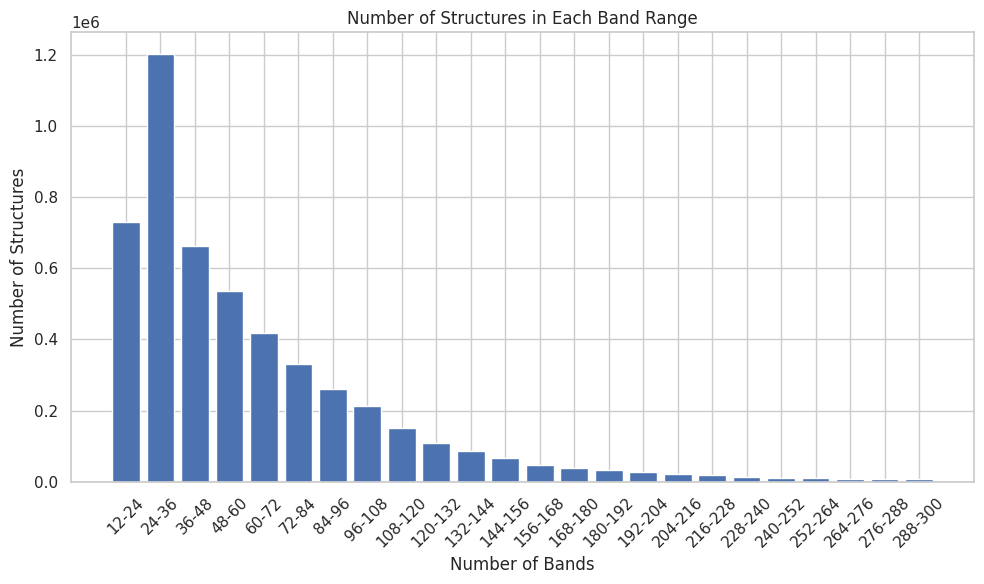

In [10]:
#bar diagram of number of structures in each band range
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")    
plt.figure(figsize=(10, 6))
plt.bar(band_index_dictionary.keys(), [len(indices) for indices in band_index_dictionary.values()])
plt.xlabel("Number of Bands")
plt.ylabel("Number of Structures")
plt.title("Number of Structures in Each Band Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
hf_dataset_24 = hf_dataset.select(band_index_dictionary["12-24"])
cost = np.array(hf_dataset_24["cost"])
cost_idx = np.argsort(cost)
hf_dataset_24 = hf_dataset_24.select(cost_idx)

In [12]:
#already sorted by cost, take 100 random samples from each 100k structures, 100 random samples 0-100k, 100 random samples 100k-200k, 100 random samples 200k-300k... 700k-length of hf_dataset_24
idx = [np.random.randint(1e5*i, 1e5*(i+1), size=100) for i in range(7)] + [np.random.randint(700000, len(hf_dataset_24), size=100)]
small_batches = [hf_dataset_24.select(indices) for indices in idx]

In [17]:
metadata_keys = ['elements',
 'nsites',
 'chemical_formula_anonymous',
 'chemical_formula_reduced',
 'nperiodic_dimensions',
 'lattice_vectors',
 'immutable_id',
 'last_modified',
 'stress_tensor',
 'energy',
 'energy_corrected',
 'forces',
 'total_magnetization',
 'charges',
 'dos_ef',
 'functional',
 'cross_compatibility',
 'bawl_fingerprint',
 'space_group_it_number',
 'nbands',
 'n_irr_kpts',
 'cost']

In [18]:
batch_metadata_general = {"Description": "each minibatch 100 random structures from hf_24, increasing different cost intervals","BANDS24": 1, "Phase": "test"}

In [24]:
import run_utilities, run_calculation
for i, batch in enumerate(small_batches):
    batch_metadata = batch_metadata_general.copy()
    batch_metadata['sub_batch_id'] = i + 1
    batch_metadata['min_nkpts_irreducible'] = np.min(batch['n_irr_kpts'])
    batch_metadata['max_nkpts_irreducible'] = np.max(batch['n_irr_kpts'])
    batch_metadata['min_cost'] = np.min(batch['cost'])
    batch_metadata['max_cost'] = np.max(batch['cost'])
    batch_metadata['min_nbands'] = np.min(batch['nbands'])
    batch_metadata['max_nbands'] = np.max(batch['nbands'])
    print(f"Batch {i+1} metadata: {batch_metadata}")
    mat_ids = batch['immutable_id']
    structure_list = structures_hf_dataset(batch, num_proc=2) 
    values = [batch[key] for key in metadata_keys]
    metadata_list = [dict(zip(metadata_keys, v)) for v in zip(*values)]
    run_utilities.run_batch(
        metadata_list=metadata_list,
        structure_list=structure_list,
        batch_metadata=batch_metadata,
        calc_func=run_calculation.relax_start_pbe,
        ncore=8,
        kpar=1,
        nbands=batch['nbands'],
        nkpts=batch['n_irr_kpts'],
        ignore_memory_check=True,
        worker="euler_24", # Adjust this worker name as needed
        launchpad_path="your_launchpad_path_here",  # Adjust this path as needed
    )

Batch 1 metadata: {'Description': 'each minibatch 100 random structures from hf_24, increasing different cost intervals', 'BANDS24': 1, 'Phase': 'test', 'sub_batch_id': 1, 'min_nkpts_irreducible': 10, 'max_nkpts_irreducible': 172, 'min_cost': 13668750, 'max_cost': 67108864, 'min_nbands': 12, 'max_nbands': 23}
Batch 2 metadata: {'Description': 'each minibatch 100 random structures from hf_24, increasing different cost intervals', 'BANDS24': 1, 'Phase': 'test', 'sub_batch_id': 2, 'min_nkpts_irreducible': 18, 'max_nkpts_irreducible': 400, 'min_cost': 69330772, 'max_cost': 114354828, 'min_nbands': 12, 'max_nbands': 22}
Batch 3 metadata: {'Description': 'each minibatch 100 random structures from hf_24, increasing different cost intervals', 'BANDS24': 1, 'Phase': 'test', 'sub_batch_id': 3, 'min_nkpts_irreducible': 18, 'max_nkpts_irreducible': 333, 'min_cost': 114354828, 'max_cost': 167448141, 'min_nbands': 13, 'max_nbands': 23}
Batch 4 metadata: {'Description': 'each minibatch 100 random str